## Objectives

This notebook develops forecasting models to predict future product demand.

The following models will be implemented:

- Moving Average Forecast
- ARIMA Forecast

The models will be evaluated using:

- RMSE
- MAPE

Finally, a 90-day demand forecast will be generated.

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [38]:
df = pd.read_csv(
    "data/processed/clean_sales.csv",
    parse_dates=["date"]
)

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [39]:
df.set_index("date", inplace=True)

In [40]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1826 entries, 2019-01-01 to 2023-12-31
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   store_id  1826 non-null   str    
 1   item_id   1826 non-null   str    
 2   sales     1826 non-null   int64  
 3   price     1826 non-null   float64
 4   promo     1826 non-null   int64  
 5   weekday   1826 non-null   int64  
 6   month     1826 non-null   int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 137.3 KB


In [41]:
df.describe()

,sales,price,promo,weekday,month
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,44.780942,20.870734,0.100767,3.001643,6.523549
std,13.761220,1.282695,0.301102,1.999862,3.449478
min,16.000000,17.040000,0.000000,0.000000,1.000000
25%,35.000000,21.300000,0.000000,1.000000,4.000000
50%,43.000000,21.300000,0.000000,3.000000,7.000000
75%,53.000000,21.300000,0.000000,5.000000,10.000000
max,107.000000,21.300000,1.000000,6.000000,12.000000


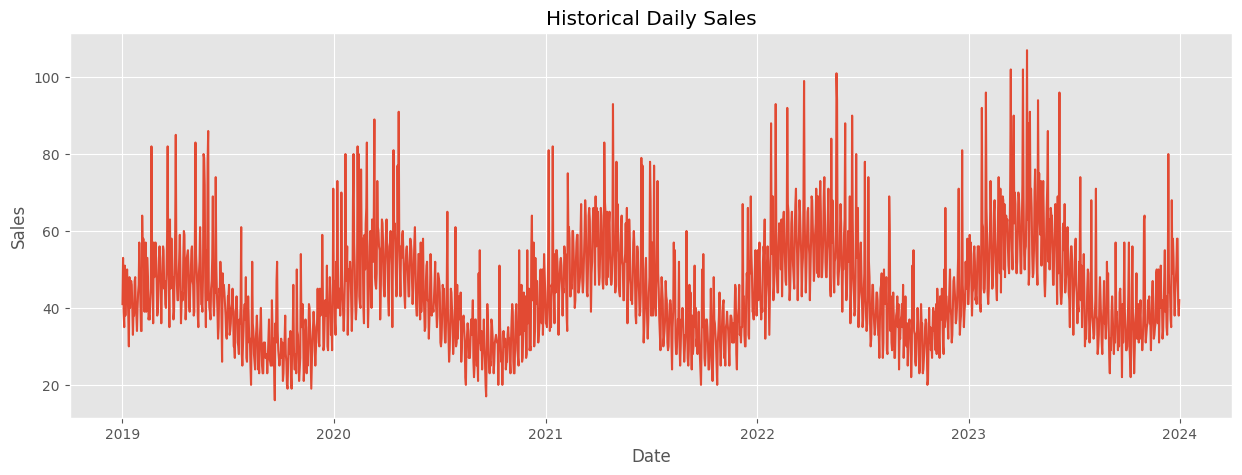

In [42]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["sales"]
)

plt.title("Historical Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [43]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

In [44]:
print("Training Records:", len(train))
print("Testing Records :", len(test))

Training Records: 1460
Testing Records : 366


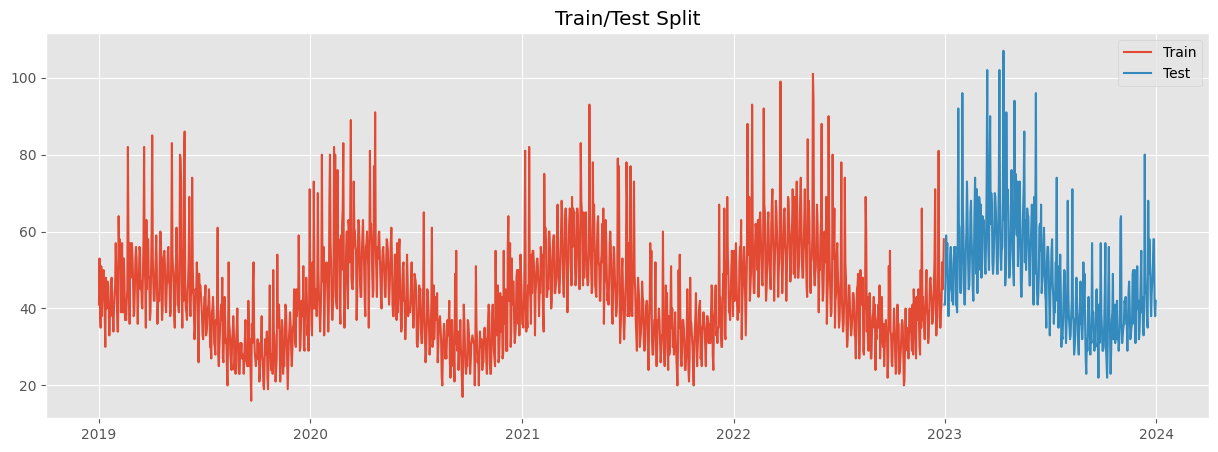

In [45]:
plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["sales"],
    label="Train"
)

plt.plot(
    test.index,
    test["sales"],
    label="Test"
)

plt.legend()

plt.title("Train/Test Split")

plt.show()

In [46]:
from src.forecasting import (
    moving_average_forecast,
    train_arima,
    arima_forecast,
    forecast_future
)

In [47]:
ma_predictions = moving_average_forecast(
    train,
    test,
    column="sales",
    window=7
)

print(ma_predictions[:10])

[np.float64(45.57142857142857), np.float64(46.42857142857143), np.float64(46.714285714285715), np.float64(47.714285714285715), np.float64(48.714285714285715), np.float64(49.857142857142854), np.float64(51.0), np.float64(49.285714285714285), np.float64(48.857142857142854), np.float64(49.285714285714285)]


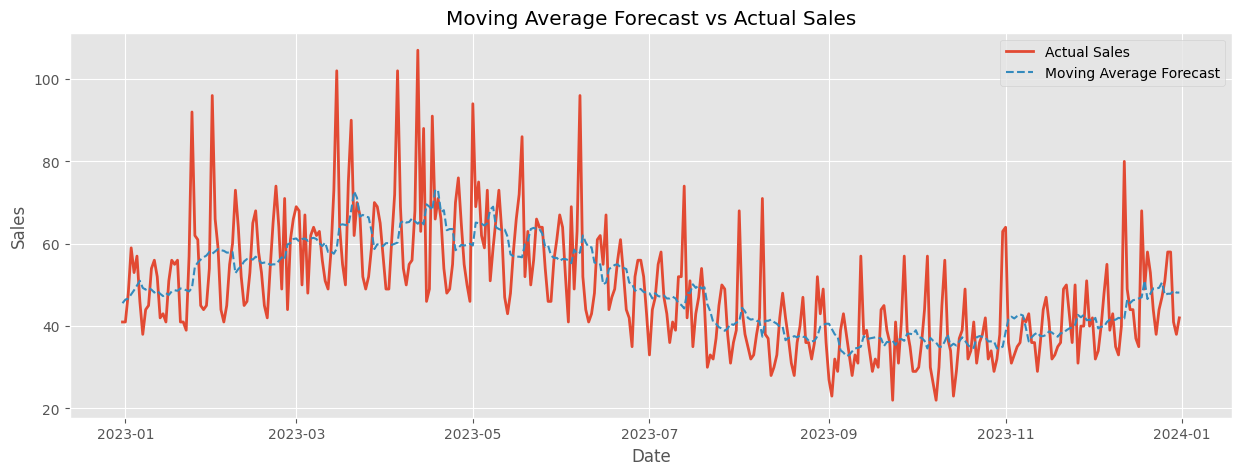

In [48]:
plt.figure(figsize=(15,5))

plt.plot(
    test.index,
    test["sales"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test.index,
    ma_predictions,
    label="Moving Average Forecast",
    linestyle="--"
)

plt.title("Moving Average Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [49]:
arima_model = train_arima(
    train,
    column="sales",
    order=(5,1,0)
)

C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [50]:
arima_predictions = arima_forecast(
    arima_model,
    len(test)
)

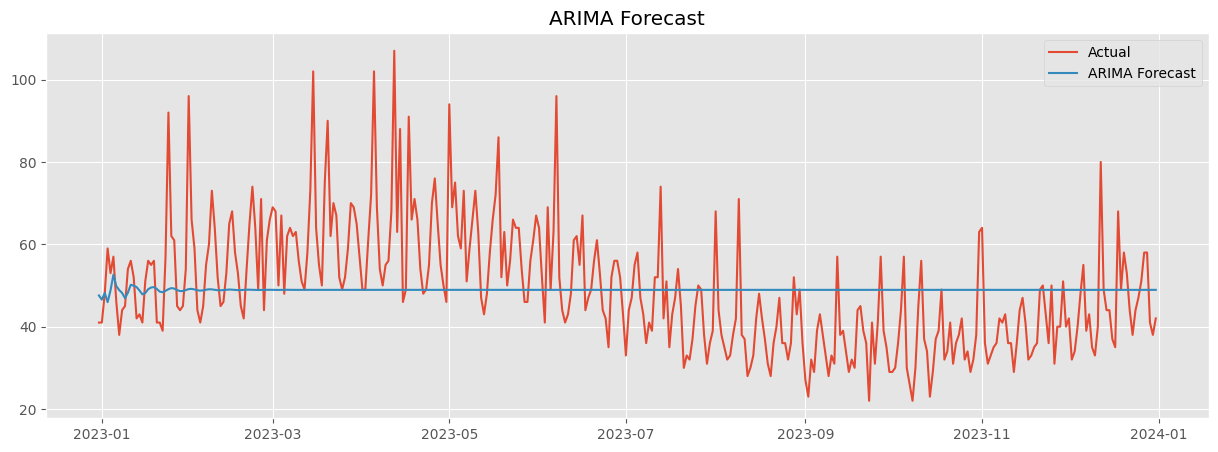

In [51]:
plt.figure(figsize=(15,5))

plt.plot(
    test.index,
    test["sales"],
    label="Actual"
)

plt.plot(
    test.index,
    arima_predictions,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast")

plt.legend()

plt.show()

In [52]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)
import numpy as np

In [53]:
ma_rmse = np.sqrt(
    mean_squared_error(
        test["sales"],
        ma_predictions
    )
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test["sales"],
        arima_predictions
    )
)

ma_mae = mean_absolute_error(
    test["sales"],
    ma_predictions
)

arima_mae = mean_absolute_error(
    test["sales"],
    arima_predictions
)

In [54]:
ma_mape = (
    np.abs(
        (test["sales"] - ma_predictions)
        / test["sales"]
    ).mean()
) * 100

arima_mape = (
    np.abs(
        (test["sales"] - arima_predictions)
        / test["sales"]
    ).mean()
) * 100

In [55]:
comparison = pd.DataFrame({
    "Model": ["Moving Average", "ARIMA"],
    "RMSE": [ma_rmse, arima_rmse],
    "MAE": [ma_mae, arima_mae],
    "MAPE (%)": [ma_mape, arima_mape]
})

comparison

,Model,RMSE,MAE,MAPE (%)
0,Moving Average,11.241718,8.421936,17.266362
1,ARIMA,14.689772,11.520571,25.080731


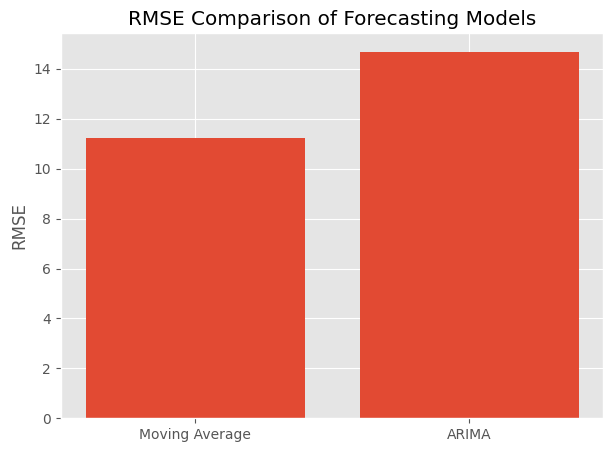

In [56]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("RMSE Comparison of Forecasting Models")
plt.ylabel("RMSE")

plt.show()

In [57]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print(f"Best Performing Model: {best_model}")

Best Performing Model: Moving Average


In [58]:
future_forecast = forecast_future(
    df,
    column="sales",
    periods=90
)

future_forecast.head()

C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Jainam\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,date,forecast_sales
2024-01-01,2024-01-01,46.199384
2024-01-02,2024-01-02,53.361319
2024-01-03,2024-01-03,54.593042
2024-01-04,2024-01-04,47.789358
2024-01-05,2024-01-05,43.542262


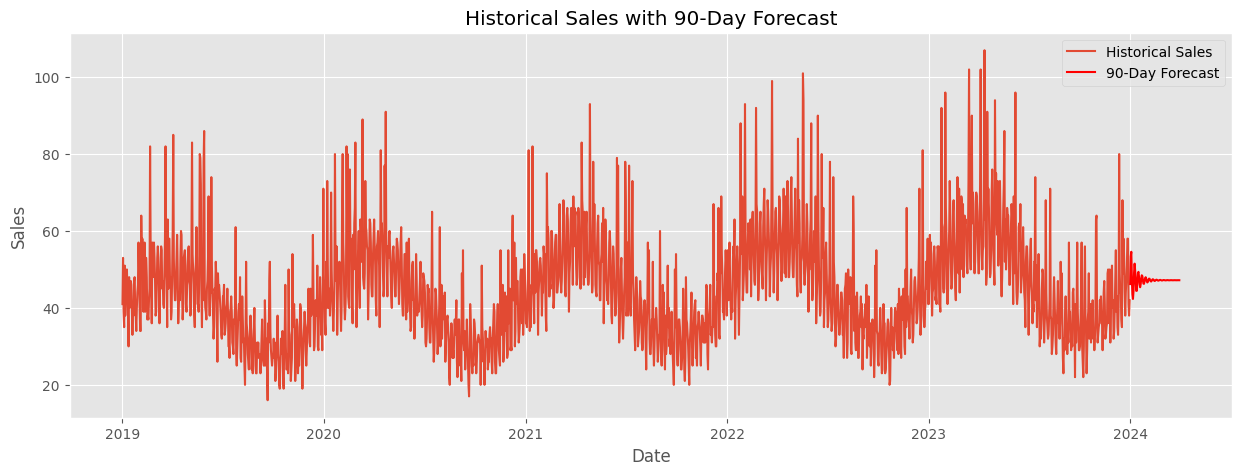

In [59]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["sales"],
    label="Historical Sales"
)

plt.plot(
    future_forecast["date"],
    future_forecast["forecast_sales"],
    color="red",
    label="90-Day Forecast"
)

plt.title("Historical Sales with 90-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [60]:
future_forecast.to_csv(
    "data/processed/future_forecast.csv",
    index=False
)

print("Future forecast saved successfully!")

Future forecast saved successfully!


# Conclusion

In this notebook, two forecasting approaches were implemented and evaluated:

- Moving Average
- ARIMA

The models were assessed using RMSE, MAE, and MAPE. Based on the evaluation metrics, the better-performing model was selected to generate a 90-day demand forecast.

The forecast has been saved and will be integrated into the Streamlit dashboard in Week 4.